# Detecting and Removing Outliers in Python



**Objectives:**
- Understand what outliers are and why they matter
- Detect outliers using visual (boxplot, scatter), Z-score and IQR methods
---

In [ ]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from scipy import stats


## 1) Load dataset (Diabetes) and quick look

In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes

In [ ]:
d = load_diabetes()



df=pd.DataFrame(data=d.data,columns=d.feature_names)

df['target']=d.target
display(df)
display(df.head(19))
df.tail()


# df = pd.DataFrame(data=data.data, columns=data.feature_names)
# df['target'] = data.target
# df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [ ]:
# Quick descriptive statistics
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


## 2) Visualizations: Boxplot (univariate) and Scatter (bivariate)

In [ ]:
import matplotlib.pyplot as plt

<Figure size 8000x400 with 0 Axes>

<Figure size 8000x400 with 0 Axes>

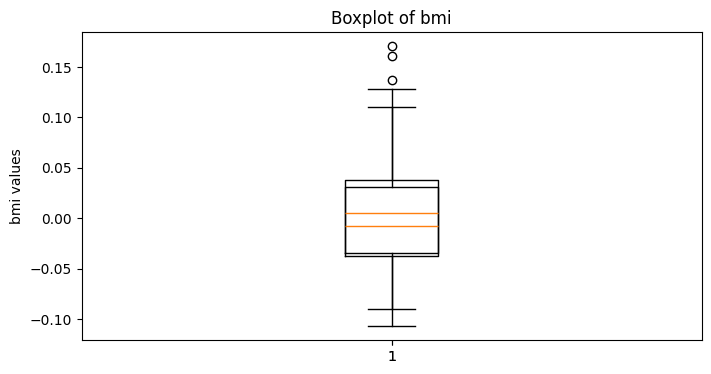

In [ ]:
# Boxplot for a single feature e.g., 'bmi'
plt.figure(figsize=(8,4))
plt.boxplot(df['bmi'])
plt.boxplot(df['age'])
plt.title('Boxplot of bmi')
plt.ylabel('bmi values')
plt.show()

/tmp/ipython-input-3958405212.py:3: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(df['bmi'], df['s1'], alpha=0.9,c="red",marker="+",edgecolor="blue",linewidths=6)


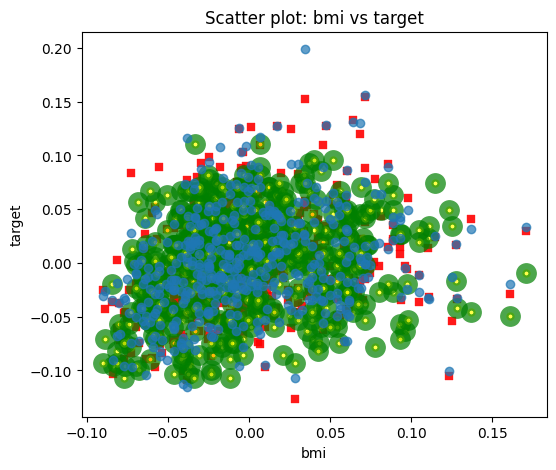

In [ ]:


# Scatter plot: bmi vs target
plt.figure(figsize=(6,5))
plt.scatter(df['bmi'], df['s1'], alpha=0.9,c="red",marker="+",edgecolor="blue",linewidths=6)
plt.scatter(df['bmi'], df['age'], alpha=0.7,c="yellow",edgecolor="green",linewidths=9)
plt.scatter(df['bmi'], df['s2'], alpha=0.7)
plt.xlabel('bmi')
plt.ylabel('target')
plt.title('Scatter plot: bmi vs target')
plt.show()

## 3) Z-score method (univariate)

Compute Z-score and remove rows where absolute Z-score > threshold (commonly 3).

In [ ]:
from scipy import stats
import numpy as np

In [ ]:
# Z-score method applied to 'bmi'
z_scores = np.abs(stats.zscore(df['bmi'].values))
print(z_scores)

[1.29708846 1.08218016 0.93453324 0.24377122 0.76494435 0.85558315
 0.99154136 0.03983391 1.29708846 0.82123474 1.7619712  0.36804071
 0.60632644 0.03983391 0.53834734 0.37972943 0.88921384 0.25474221
 0.22111152 0.37972943 1.19547867 0.47036823 0.08515331 1.27442876
 0.75325563 0.26643092 1.62601299 1.25176906 0.44770853 0.13047271
 0.93453324 1.37675628 2.63401083 1.05952046 1.33143688 0.65164584
 0.48133922 0.23208251 1.50102577 0.30006161 0.17579212 1.42207568
 0.22111152 0.49302793 1.43304667 0.74228465 0.24377122 1.53537419
 0.87824285 0.30006161 0.15313242 0.34538101 0.19845182 0.33441002
 0.52665862 1.03686076 0.86655414 1.33143688 1.35409658 0.53834734
 0.08515331 0.0961243  0.15313242 0.78760405 0.53834734 0.51568763
 0.37972943 0.31175032 0.62898614 0.96888166 1.46739509 0.70793623
 0.08515331 0.42504883 0.0508049  0.65164584 0.59463772 0.76494435
 1.21813837 0.78760405 0.25474221 0.47036823 0.74228465 0.2094228
 0.83292345 1.50102577 1.58069359 0.13047271 0.85558315 1.01420

In [ ]:
threshold = 3
outliers_z = np.where(z_scores > threshold)[0]

print(outliers_z)
print(len(outliers_z))

[256 367]
2


In [ ]:
df.shape

(442, 11)

In [ ]:
df_remove=df.drop(index=outliers_z).reset_index(drop=True)
display(df_remove)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
435,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
436,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
437,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
438,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [ ]:


print(f'Number of outliers detected by Z-score (threshold=3) in bmi: {len(outliers_z)}')
df_z_removed = df.drop(index=outliers_z).reset_index(drop=True)
print('Shape before:', df.shape, 'Shape after Z-score removal:', df_z_removed.shape)

## 4) IQR method (univariate)

Compute Q1, Q3 and remove points outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR].

In [ ]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)].index
print(f'Number of outliers detected by IQR in bmi: {len(outliers_iqr)}')
df_iqr_removed = df.drop(index=outliers_iqr).reset_index(drop=True)
print('Shape before:', df.shape, 'Shape after IQR removal:', df_iqr_removed.shape)

Use the following dataset and find outliers by using various methods



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("diamonds")